In [ ]:
def get_adversarial_examples(X_train_subset, pipeline, model):
    warnings.filterwarnings('ignore')
    
    # Extract the preprocessor and model from the pipeline
    preprocessor = pipeline.named_steps['preprocessor']

    # Preprocess the subset of training data using the pipeline's preprocessor
    X_train_subset_preprocessed = preprocessor.transform(X_train_subset)

    # Create ART classifier for XGBoost
    art_classifier = XGBoostClassifier(
        model=model,
        nb_features=X_train_subset_preprocessed.shape[1],
        nb_classes=2)

    # Create the ZooAttack instance
    zoo = ZooAttack(
        classifier=art_classifier,
        confidence=0.0,
        targeted=False,
        learning_rate=1e-1,
        max_iter=15,
        binary_search_steps=10,
        initial_const=1e-3,
        abort_early=True,
        use_resize=False,
        use_importance=False,
        nb_parallel=5,
        batch_size=1,
        variable_h=0.01
    )

    # Generate adversarial examples
    x_train_adv = zoo.generate(X_train_subset_preprocessed)

    return x_train_adv

In [ ]:
'''def make_adv_samples(X_test, pipeline, model_baseline):
    x_train_adv = get_adversarial_examples(X_test, pipeline, model_baseline)
    return x_train_adv'''

ZOO:   0%|          | 0/7500 [00:00<?, ?it/s]

ZOO: 100%|██████████| 7500/7500 [04:16<00:00, 29.26it/s]

(7500, 24)


In [19]:
def calculate_attack_metrics(adv_numpy, sample_numpy, std):
    """
    Calculate attack metrics between adversarial and clean samples.

    Parameters:
    - adv_numpy: np.array (1D) adversarial example (possibly preprocessed)
    - sample_numpy: np.array (1D) clean example (same space as adv_numpy)
    - adv_numpy_cont: np.array (1D) adversarial example in continuous/raw space (optional, for Mahalanobis)
    - train_mean: np.array mean vector of training data in continuous/raw space
    - train_cov_matrix: np.array covariance matrix of training data in continuous/raw space
    - threshold: float threshold for Mahalanobis distance outlier detection
    - std: np.array standard deviation vector of training data features (same length as adv_numpy)

    Returns: dict with keys:
    - "L0 Distance", "L1 Distance", "L2 Distance", "Linf Distance", "Sensitivity"
    """
    eps = 1e-8

    # Sparsity metric: count of features changed
    l0_distance = np.count_nonzero(adv_numpy - sample_numpy)

    # Proximity metrics: norms of difference
    diff = adv_numpy - sample_numpy
    l1_distance = np.linalg.norm(diff, ord=1)
    l2_distance = np.linalg.norm(diff, ord=2)
    linf_distance = np.linalg.norm(diff, ord=np.inf)

    # Sensitivity: normalized L1 per changed feature, averaged (avoid division by zero)
    if l0_distance == 0:
        sens = 0.0
    else:
        # std could have zeros, so clip to eps to avoid div by zero
        std_safe = np.clip(std, a_min=eps, a_max=None)
        sens = (l1_distance / (np.sum(std_safe) * l0_distance))

    return {
        "L0 Distance": l0_distance,
        "L1 Distance": l1_distance,
        "L2 Distance": l2_distance,
        "Linf Distance": linf_distance,
        "Sensitivity": sens,
    }


In [20]:
def create_chart():
    # Preprocess original data
    X_orig_preprocessed = pipeline.named_steps['preprocessor'].transform(X_train_og)

    # Predict probabilities on original and adversarial samples
    y_probs_orig = model_baseline.predict_proba(X_orig_preprocessed)
    y_probs_adv = model_baseline.predict_proba(x_train_adv)

    # Get confidence in true class for each sample
    true_class_conf_orig = [prob[y] for prob, y in zip(y_probs_orig, y_train_og)]
    true_class_conf_adv = [prob[y] for prob, y in zip(y_probs_adv, y_train_og)]

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(true_class_conf_orig[:20], label='Before ZOO (Original)', marker='o')
    plt.plot(true_class_conf_adv[:20], label='After ZOO (Adversarial)', marker='x')
    plt.title('Model Confidence in True Class Before vs After ZOO Attack (Sample of 100)')
    plt.xlabel('Sample Index')
    plt.ylabel('Confidence in True Class')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [21]:
#without any defense, directly testing how much model is impacted

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

def main_metrics():
    # Predictions on the test set (which is actually adversarial)
    y_adv_pred = model_baseline.predict(x_train_adv)
    y_adv_proba = model_baseline.predict_proba(x_train_adv).max(axis=1)

    # Preprocess clean test data
    X_test_proc = pipeline.named_steps['preprocessor'].transform(X_test)
    x_train_adv_np = np.array(x_train_adv)

    # Safety check
    assert X_test_proc.shape == x_train_adv_np.shape, "Shape mismatch between clean and adversarial sets."

    # Loop over each (clean, adversarial) pair and compute metrics
    all_metrics = [
        calculate_attack_metrics(adv_sample, clean_sample, train_std)
        for adv_sample, clean_sample in zip(x_train_adv_np, X_test_proc)
    ]

    # Convert results to DataFrame
    results_df = pd.DataFrame(all_metrics)

    # Summary metrics
    avg_l0 = results_df["L0 Distance"].mean()
    avg_l2 = results_df["L2 Distance"].mean()
    avg_linf = results_df["Linf Distance"].mean()

    # Compute accuracy on the test set
    accuracy_test = accuracy_score(y_test, y_adv_pred)
    print(f"Accuracy on Test Set wihtout any defense: {accuracy_test * 100:.2f}%")

    # Confusion Matrix for test data
    cm_test = confusion_matrix(y_test, y_adv_pred)

    # Plot Confusion Matrix for the test set
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    # Drop in prediction confidence
    confidence_drop = np.mean(y_adv_proba - y_proba)

    # Attack success rate
    attack_success_rate = np.mean(y_pred_baseline != y_adv_pred)

    # (Optional) Print full summary
    print(results_df.describe())

    # Metrics
    metrics_table = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "F1 Score",
            "Precision",
            "Recall",
            "ROC-AUC",
            "Avg L0 Distance",
            "Avg L2 Distance",
            "Avg Linf Distance",
            "Confidence Drop",
            "Attack Success Rate"
        ],
        "Clean": [
            accuracy_score(y_test, y_pred_baseline),
            f1_score(y_test, y_pred_baseline),
            precision_score(y_test, y_pred_baseline),
            recall_score(y_test, y_pred_baseline),
            roc_auc_score(y_test, model_baseline.predict_proba(X_test_proc)[:, 1]),
            np.nan,  # L0 not meaningful for clean
            np.nan,  # L2 not meaningful for clean
            np.nan,  # Linf not meaningful for clean
            0.0,     # No confidence drop on clean
            0.0
        ],
        "Adversarial": [
            accuracy_score(y_test, y_adv_pred),
            f1_score(y_test, y_adv_pred),
            precision_score(y_test, y_adv_pred),
            recall_score(y_test, y_adv_pred),
            roc_auc_score(y_test, model_baseline.predict_proba(x_train_adv)[:, 1]),
            avg_l0,
            avg_l2,
            avg_linf,
            confidence_drop,
            attack_success_rate
        ]
    })

    # Compute change for interpretation
    metrics_table["Change"] = metrics_table["Adversarial"] - metrics_table["Clean"]

    # Format table
    pd.options.display.float_format = '{:.4f}'.format
    return metrics_table

/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:23:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model Accuracy: 0.8240
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      5860
           1       0.67      0.39      0.49      1640

    accuracy                           0.82      7500
   macro avg       0.76      0.67      0.69      7500
weighted avg       0.81      0.82      0.81      7500


Final Training Log Loss: 0.3043
Final Test Log Loss: 0.4250


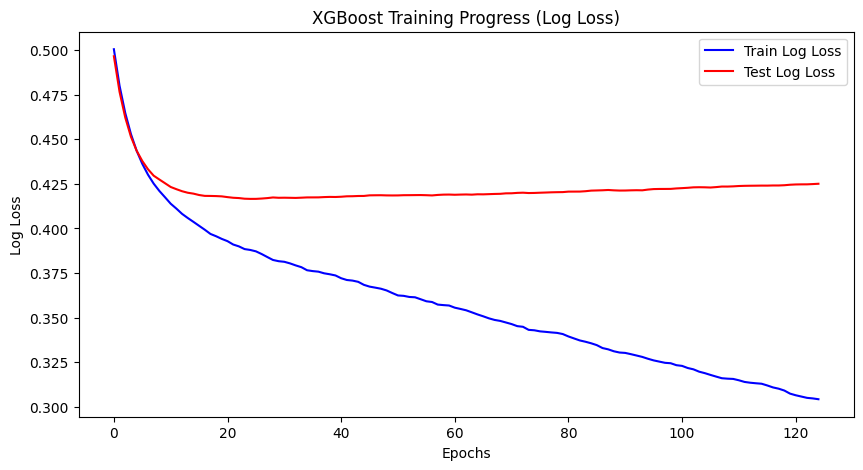

Baseline Model Results: {'accuracy': 0.824, 'precision': 0.6652892561983471, 'recall': 0.3926829268292683, 'f1': 0.4938650306748466, 'roc_auc': 0.6730966973278948}


In [1]:
#ZOO and Label flip attacks on the baseline model

%run /home/jui/thesis-code/Thesis-code/RAI-implementation/Baseline-model.ipynb
X_train_np = X_train_og.to_numpy()

train_mean = np.mean(X_train_np, axis=0)
train_cov_matrix = np.cov(X_train_np, rowvar=False)
train_std = np.std(X_train_np, axis=0)

ZOO:   0%|          | 0/7500 [00:00<?, ?it/s]

ZOO: 100%|██████████| 7500/7500 [03:29<00:00, 35.85it/s]


Accuracy on Test Set wihtout any defense: 71.09%


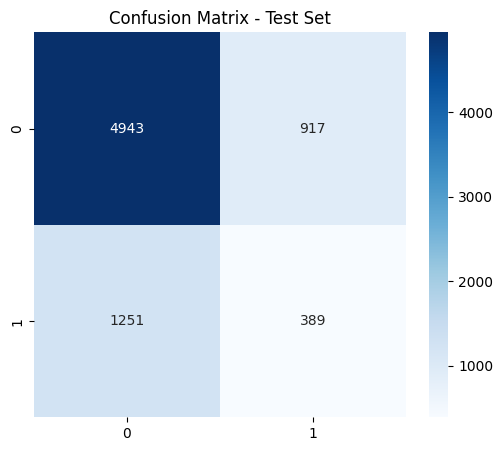

       L0 Distance  L1 Distance  L2 Distance  Linf Distance   Sensitivity
count  7500.000000  7500.000000  7500.000000    7500.000000  7.500000e+03
mean      1.422400     0.385429     0.152271       0.084201  8.679116e-08
std       2.783753     1.259548     0.430281       0.223729  1.963522e-07
min       0.000000     0.000000     0.000000       0.000000  0.000000e+00
25%       0.000000     0.000000     0.000000       0.000000  0.000000e+00
50%       0.000000     0.000000     0.000000       0.000000  0.000000e+00
75%       2.000000     0.199979     0.141407       0.099997  1.540778e-07
max      16.000000    22.698492     6.779972       2.851510  2.914856e-06


ZOO: 100%|██████████| 7500/7500 [03:29<00:00, 35.72it/s]


Accuracy on Test Set wihtout any defense: 70.83%


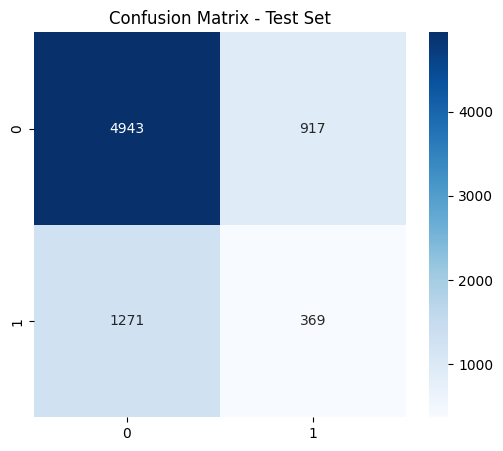

       L0 Distance  L1 Distance  L2 Distance  Linf Distance  Sensitivity
count    7500.0000    7500.0000    7500.0000      7500.0000    7500.0000
mean        1.3971       0.3671       0.1456         0.0805       0.0000
std         2.7604       1.1869       0.4051         0.2093       0.0000
min         0.0000       0.0000       0.0000         0.0000       0.0000
25%         0.0000       0.0000       0.0000         0.0000       0.0000
50%         0.0000       0.0000       0.0000         0.0000       0.0000
75%         2.0000       0.2000       0.1414         0.1000       0.0000
max        17.0000      18.0295       5.7207         2.4876       0.0000


ZOO: 100%|██████████| 7500/7500 [03:30<00:00, 35.60it/s]


Accuracy on Test Set wihtout any defense: 70.73%


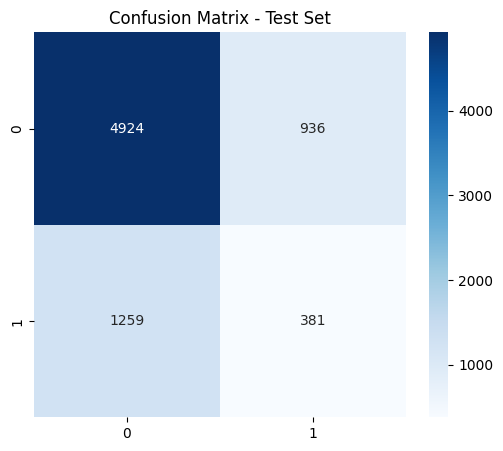

       L0 Distance  L1 Distance  L2 Distance  Linf Distance  Sensitivity
count    7500.0000    7500.0000    7500.0000      7500.0000    7500.0000
mean        1.4463       0.3880       0.1524         0.0844       0.0000
std         2.8226       1.2573       0.4228         0.2191       0.0000
min         0.0000       0.0000       0.0000         0.0000       0.0000
25%         0.0000       0.0000       0.0000         0.0000       0.0000
50%         0.0000       0.0000       0.0000         0.0000       0.0000
75%         2.0000       0.2000       0.1414         0.1000       0.0000
max        17.0000      16.9624       5.5170         2.5135       0.0000


ZOO: 100%|██████████| 7500/7500 [03:29<00:00, 35.78it/s]


Accuracy on Test Set wihtout any defense: 70.89%


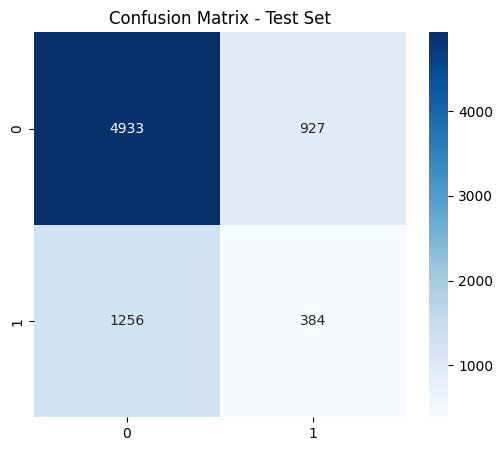

       L0 Distance  L1 Distance  L2 Distance  Linf Distance  Sensitivity
count    7500.0000    7500.0000    7500.0000      7500.0000    7500.0000
mean        1.4157       0.3778       0.1495         0.0831       0.0000
std         2.7912       1.2057       0.4129         0.2168       0.0000
min         0.0000       0.0000       0.0000         0.0000       0.0000
25%         0.0000       0.0000       0.0000         0.0000       0.0000
50%         0.0000       0.0000       0.0000         0.0000       0.0000
75%         2.0000       0.2000       0.1414         0.1000       0.0000
max        17.0000      17.2591       4.5898         3.1340       0.0000


ZOO: 100%|██████████| 7500/7500 [03:30<00:00, 35.60it/s]


Accuracy on Test Set wihtout any defense: 70.85%


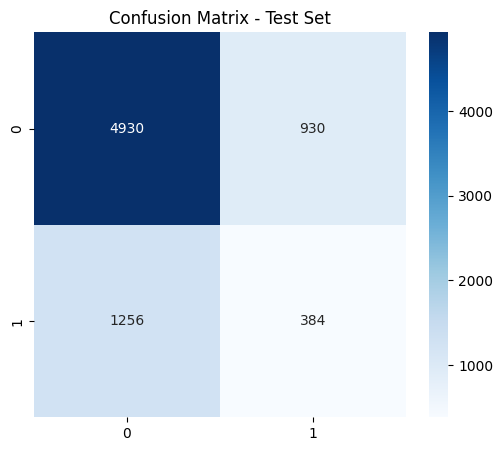

       L0 Distance  L1 Distance  L2 Distance  Linf Distance  Sensitivity
count    7500.0000    7500.0000    7500.0000      7500.0000    7500.0000
mean        1.4161       0.3664       0.1466         0.0819       0.0000
std         2.7669       1.1289       0.3912         0.2076       0.0000
min         0.0000       0.0000       0.0000         0.0000       0.0000
25%         0.0000       0.0000       0.0000         0.0000       0.0000
50%         0.0000       0.0000       0.0000         0.0000       0.0000
75%         2.0000       0.2000       0.1414         0.1000       0.0000
max        17.0000      13.7475       3.9789         2.3565       0.0000


In [23]:
from art.estimators.classification import XGBoostClassifier
from art.attacks.evasion import ZooAttack
from art.estimators.classification import SklearnClassifier
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import warnings
import nbimporter

metrics_list1 = []  # For attack metrics: L0, L2, etc.
metrics_list2 = []  # For model performance: accuracy, precision, etc.

for i in range(5):    
    x_train_adv = get_adversarial_examples(X_test, pipeline, model_baseline)
    
    # 1. Collect distance/sensitivity metrics
    metrics = calculate_attack_metrics(
        x_train_adv, 
        pipeline.named_steps['preprocessor'].transform(X_test), 
        train_std
    )
    metrics_list1.append(metrics)
    
    # 2. Collect model performance metrics
    metrics_table = main_metrics()
    metrics_list2.append(metrics_table)

#  Create DataFrame for attack metrics
attack_metrics_df = pd.DataFrame(metrics_list1)

# Mean and std of attack metrics
avg_attack_metrics = attack_metrics_df.mean().to_dict()
std_attack_metrics = attack_metrics_df.std().to_dict()

#  Combine all performance metrics and compute averages
all_metrics_df = pd.concat(metrics_list2, ignore_index=True)

# Group by metric name and take mean of Clean and Adversarial columns
averaged_metrics = (
    all_metrics_df
    .groupby("Metric")[["Clean", "Adversarial"]]
    .mean()
    .reset_index()
)

# Optional: Add Change column
averaged_metrics["Change"] = averaged_metrics["Adversarial"] - averaged_metrics["Clean"]


In [24]:
print(averaged_metrics)

# Compute std deviation for Clean and Adversarial
std_metrics = (
    all_metrics_df
    .groupby("Metric")[["Clean", "Adversarial"]]
    .std()
    .reset_index()
)

# Rename std columns for clarity
std_metrics = std_metrics.rename(columns={
    "Clean": "Clean_Std",
    "Adversarial": "Adversarial_Std"
})

# Merge with averaged_metrics
final_metrics = averaged_metrics.merge(std_metrics, on="Metric")

print(final_metrics)

                Metric  Clean  Adversarial  Change
0             Accuracy 0.8240       0.7088 -0.1152
1  Attack Success Rate 0.0000       0.2983  0.2983
2      Avg L0 Distance    NaN       1.4195     NaN
3      Avg L2 Distance    NaN       0.1493     NaN
4    Avg Linf Distance    NaN       0.0828     NaN
5      Confidence Drop 0.0000       0.5989  0.5989
6             F1 Score 0.4939       0.2588 -0.2350
7            Precision 0.6653       0.2918 -0.3734
8              ROC-AUC 0.7828       0.7123 -0.0705
9               Recall 0.3927       0.2326 -0.1601
                Metric  Clean  Adversarial  Change  Clean_Std  Adversarial_Std
0             Accuracy 0.8240       0.7088 -0.1152     0.0000           0.0013
1  Attack Success Rate 0.0000       0.2983  0.2983     0.0000           0.0014
2      Avg L0 Distance    NaN       1.4195     NaN        NaN           0.0177
3      Avg L2 Distance    NaN       0.1493     NaN        NaN           0.0032
4    Avg Linf Distance    NaN       0.0828  

In [2]:
def label_flip_attack(y_train: np.ndarray, flip_percent: float) -> np.ndarray:
    """
    Flip labels in y_train by a specified percentage.
    
    Args:
        y_train (np.ndarray): Original training labels.
        flip_percent (float): Percentage of labels to flip (0-100).

    Returns:
        np.ndarray: Poisoned labels with flipped values.
    """
    y_poisoned = y_train.copy()
    n_samples = len(y_train)
    n_flip = int((flip_percent / 100) * n_samples)  # Number of labels to flip
    
    flip_indices = np.random.choice(np.arange(n_samples), size=n_flip, replace=False)

    # Flip binary labels (assuming labels are 0 and 1)
    y_poisoned[flip_indices] = 1 - y_poisoned[flip_indices]  # Flip 0->1 and 1->0
    
    return y_poisoned



In [3]:
# Define the percentage of labels to flip

def use_label_flip_attack(y_train_og, X_train_og, X_test, y_test, flip_percent):
    # Apply label flipping attack
    y_train_poisoned = label_flip_attack(y_train_og, flip_percent)

    # Step 2: Train model on poisoned labels
    model_poisoned = xgb_model.fit(X_train_og, y_train_poisoned, verbose=False)
    y_proba_poisoned = xgb_model.predict_proba(X_test)[:, 1]

    # Step 3: Evaluate model on test set
    y_pred_poisoned = model_poisoned.predict(X_test)
    poisoned_accuracy = accuracy_score(y_test, y_pred_poisoned)
    print(f"Accuracy on Test Set: {poisoned_accuracy * 100:.2f}%")

    # Step 4: Confusion Matrix
    cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_poisoned, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix - Test Set")
    plt.show()
    return model_poisoned, y_pred_poisoned, y_proba_poisoned, poisoned_accuracy

In [ ]:


def evaluate_label_flip_impact(acc_clean, acc_poisoned, y_pred_clean, y_pred_poisoned, probs_clean, probs_poisoned, y_test):
    acc_drop = acc_clean - acc_poisoned

    # Prediction agreement / shift
    prediction_agreement = np.mean(y_pred_clean == y_pred_poisoned)
    prediction_shift_rate = 1 - prediction_agreement

    # Class distribution shift
    clean_counts = Counter(y_pred_clean)
    poisoned_counts = Counter(y_pred_poisoned)

    # Misclassification map (correct before, wrong after)
    correct_before = (y_pred_clean == y_test)
    wrong_after = (y_pred_poisoned != y_test)
    damaged_indices = np.where(correct_before & wrong_after)[0]
    damage_rate = len(damaged_indices) / len(y_test)

    # Confidence drop (optional)
    try:
        conf_clean = probs_clean  # already shape (7500,)
        conf_poisoned = probs_poisoned  # also 1D, same shape
        avg_conf_drop = np.mean(conf_clean - conf_poisoned)
    except AttributeError:
        avg_conf_drop = None  # model might not support predict_proba


    # Pack results into a dict
    results = {
        "Accuracy Clean": acc_clean,
        "Accuracy Poisoned": acc_poisoned,
        "Accuracy Drop": acc_drop,
        "Prediction Agreement": prediction_agreement,
        "Prediction Shift Rate": prediction_shift_rate,
        "Class Distribution Clean": dict(clean_counts),
        "Class Distribution Poisoned": dict(poisoned_counts),
        "Damage Rate": damage_rate,
        "Damaged Indices": damaged_indices,
        "Average Confidence Drop": avg_conf_drop,
    }

    return results



/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:31:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy on Test Set: 75.60%


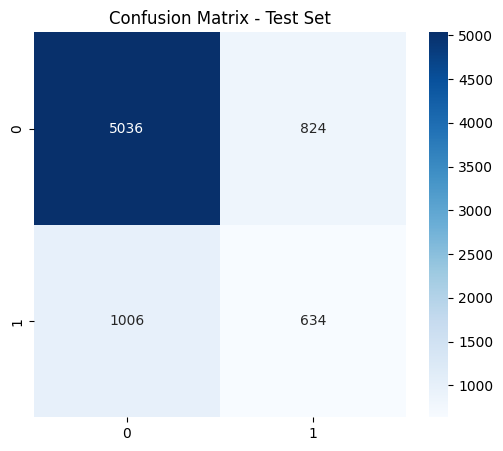

/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:31:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy on Test Set: 60.55%


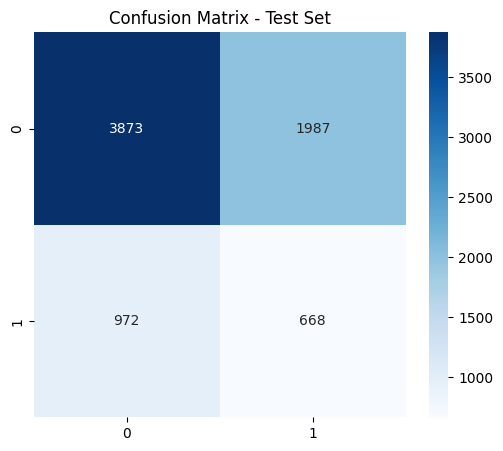

/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:31:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy on Test Set: 38.15%


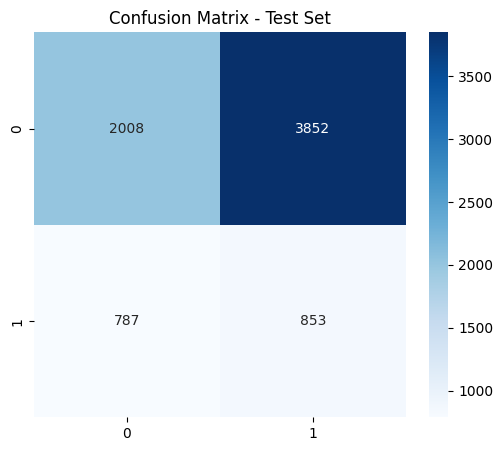

/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:31:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy on Test Set: 24.92%


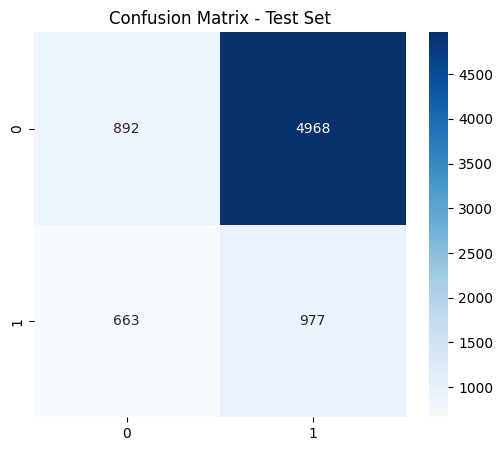

/home/jui/.pyenv/versions/3.10.12/envs/myenv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:31:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy on Test Set: 19.71%


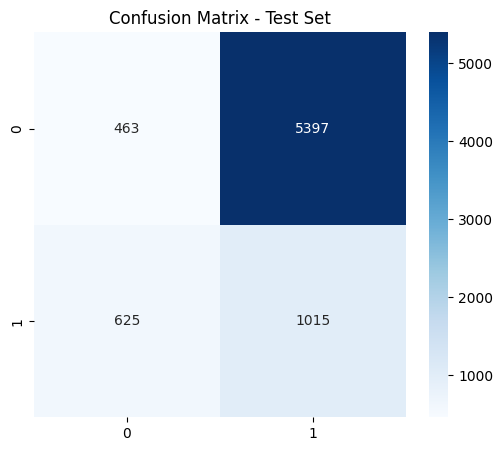

    Flip %  Accuracy Clean  Accuracy Poisoned  Accuracy Drop  \
0       35           0.824           0.756000       0.068000   
1       45           0.824           0.605467       0.218533   
2       55           0.824           0.381467       0.442533   
3       65           0.824           0.249200       0.574800   
4       75           0.824           0.197067       0.626933   
5  Average           0.824           0.437840       0.386160   
6  Std Dev           0.000           0.237728       0.237728   

   Prediction Agreement  Prediction Shift Rate Class Distribution Clean  \
0              0.846667               0.153333        {0: 6532, 1: 968}   
1              0.647600               0.352400        {0: 6532, 1: 968}   
2              0.347600               0.652400        {0: 6532, 1: 968}   
3              0.156933               0.843067        {0: 6532, 1: 968}   
4              0.077067               0.922933        {0: 6532, 1: 968}   
5              0.415173              

In [11]:
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

flip_percent = [35, 45, 55, 65, 75]
label_flip_metrics_list = []

for i in range(5):
    model_poisoned, y_pred_poisoned, y_proba_poisoned, poisoned_accuracy = use_label_flip_attack(y_train_og, X_train_og, X_test, y_test,flip_percent[i])
    metrics = evaluate_label_flip_impact(accuracy, poisoned_accuracy, y_pred_baseline, y_pred_poisoned, y_proba, y_proba_poisoned, y_test)
    metrics["Flip %"] = flip_percent[i]
    label_flip_metrics_list.append(metrics)

# Convert all results into DataFrame
label_flip_df = pd.DataFrame(label_flip_metrics_list)

# Compute mean and std only for selected numeric metrics
numeric_cols = ['Accuracy Clean', 'Accuracy Poisoned', 'Accuracy Drop', 
                'Prediction Agreement', 'Prediction Shift Rate', 
                'Damage Rate', 'Average Confidence Drop']

mean_row = label_flip_df[numeric_cols].mean()
mean_row["Flip %"] = "Average"

std_row = label_flip_df[numeric_cols].std()
std_row["Flip %"] = "Std Dev"

# Append mean and std as new rows
label_flip_final_df = pd.concat([label_flip_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
label_flip_final_df.drop(columns=["Damaged Indices"], inplace=True)
label_flip_final_df["Accuracy Clean"] = label_flip_final_df["Accuracy Clean"].astype(float).round(4)
ordered_cols = [
    "Flip %",
    "Accuracy Clean",
    "Accuracy Poisoned",
    "Accuracy Drop",
    "Prediction Agreement",
    "Prediction Shift Rate",
    "Class Distribution Clean",
    "Class Distribution Poisoned",
    "Damage Rate",
    "Average Confidence Drop"
]
label_flip_final_df = label_flip_final_df[ordered_cols]


print(label_flip_final_df)